In [1]:
import utils as ut
from datasets import load_dataset

import matplotlib.pyplot as plt
import numpy as np

2025-02-10 08:56:09.306206: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-10 08:56:09.456872: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739174169.531070 1457739 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739174169.556137 1457739 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-10 08:56:09.721173: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
hf_dataset = load_dataset("agucci/mri-sym2")

In [3]:
dst1 = hf_dataset['train'].map(ut.transforms, batched=True)
dst2 = hf_dataset['test'].map(ut.transforms, batched=True)

In [4]:
ims = []

for i in range(10):
    (im0:=dst1['slice1'][i+10].resize((290, 290)))
    (im1:=dst1['slice2'][i+10].resize((290, 290)))
    noised = ut.add_noise_range_290v2(im1, size=i)
    # display(noised)
    ims.append((im0, noised))

    (im02:=dst2['slice1'][i+10].resize((290, 290)))
    (im2:=dst2['slice2'][i+10].resize((290, 290)))
    noised2 = ut.add_noise_range_290v2(im2, size=i)
    # display(noised2)
    ims.append((im02, noised2))


In [5]:
len(ims)

20

In [27]:
def noise_grid(image_pairs, output_file='noise_grid'):
    fig, axs = plt.subplots(4, 5, figsize=(20, 16))
    fig.suptitle(' ', fontsize=16)
    plt.subplots_adjust(wspace=0, hspace=0)

    for i, (_, right_img) in enumerate(image_pairs):
        row = i // 5
        col = i % 5
        axs[row, col].imshow(np.array(right_img), cmap='gray')
        axs[row, col].axis('off')
       
    xposes = [0.15,0.2925,0.435,0.5775,0.875] # letters positions
    label = chr(65 + i)  # 65 is ASCII for 'A'

    # Columns and rows
    column_labels = ['A', 'B', 'C', 'D', 'E']
    for col, label in enumerate(column_labels):
        axs[0, col].set_title(label, fontsize=20, pad=20, weight='bold')
    row_labels = ['1', '2', '3', '4']
    for row, label in enumerate(row_labels):
        axs[row, 0].annotate(label, xy=(-0.1, 0.5), xycoords='axes fraction',
                             fontsize=20, ha='center', va='center', rotation=0, weight='bold')

    plt.tight_layout()
    plt.savefig(output_file+".png", bbox_inches='tight')
    plt.savefig(output_file+".eps", bbox_inches='tight')
    plt.show()
    plt.close()

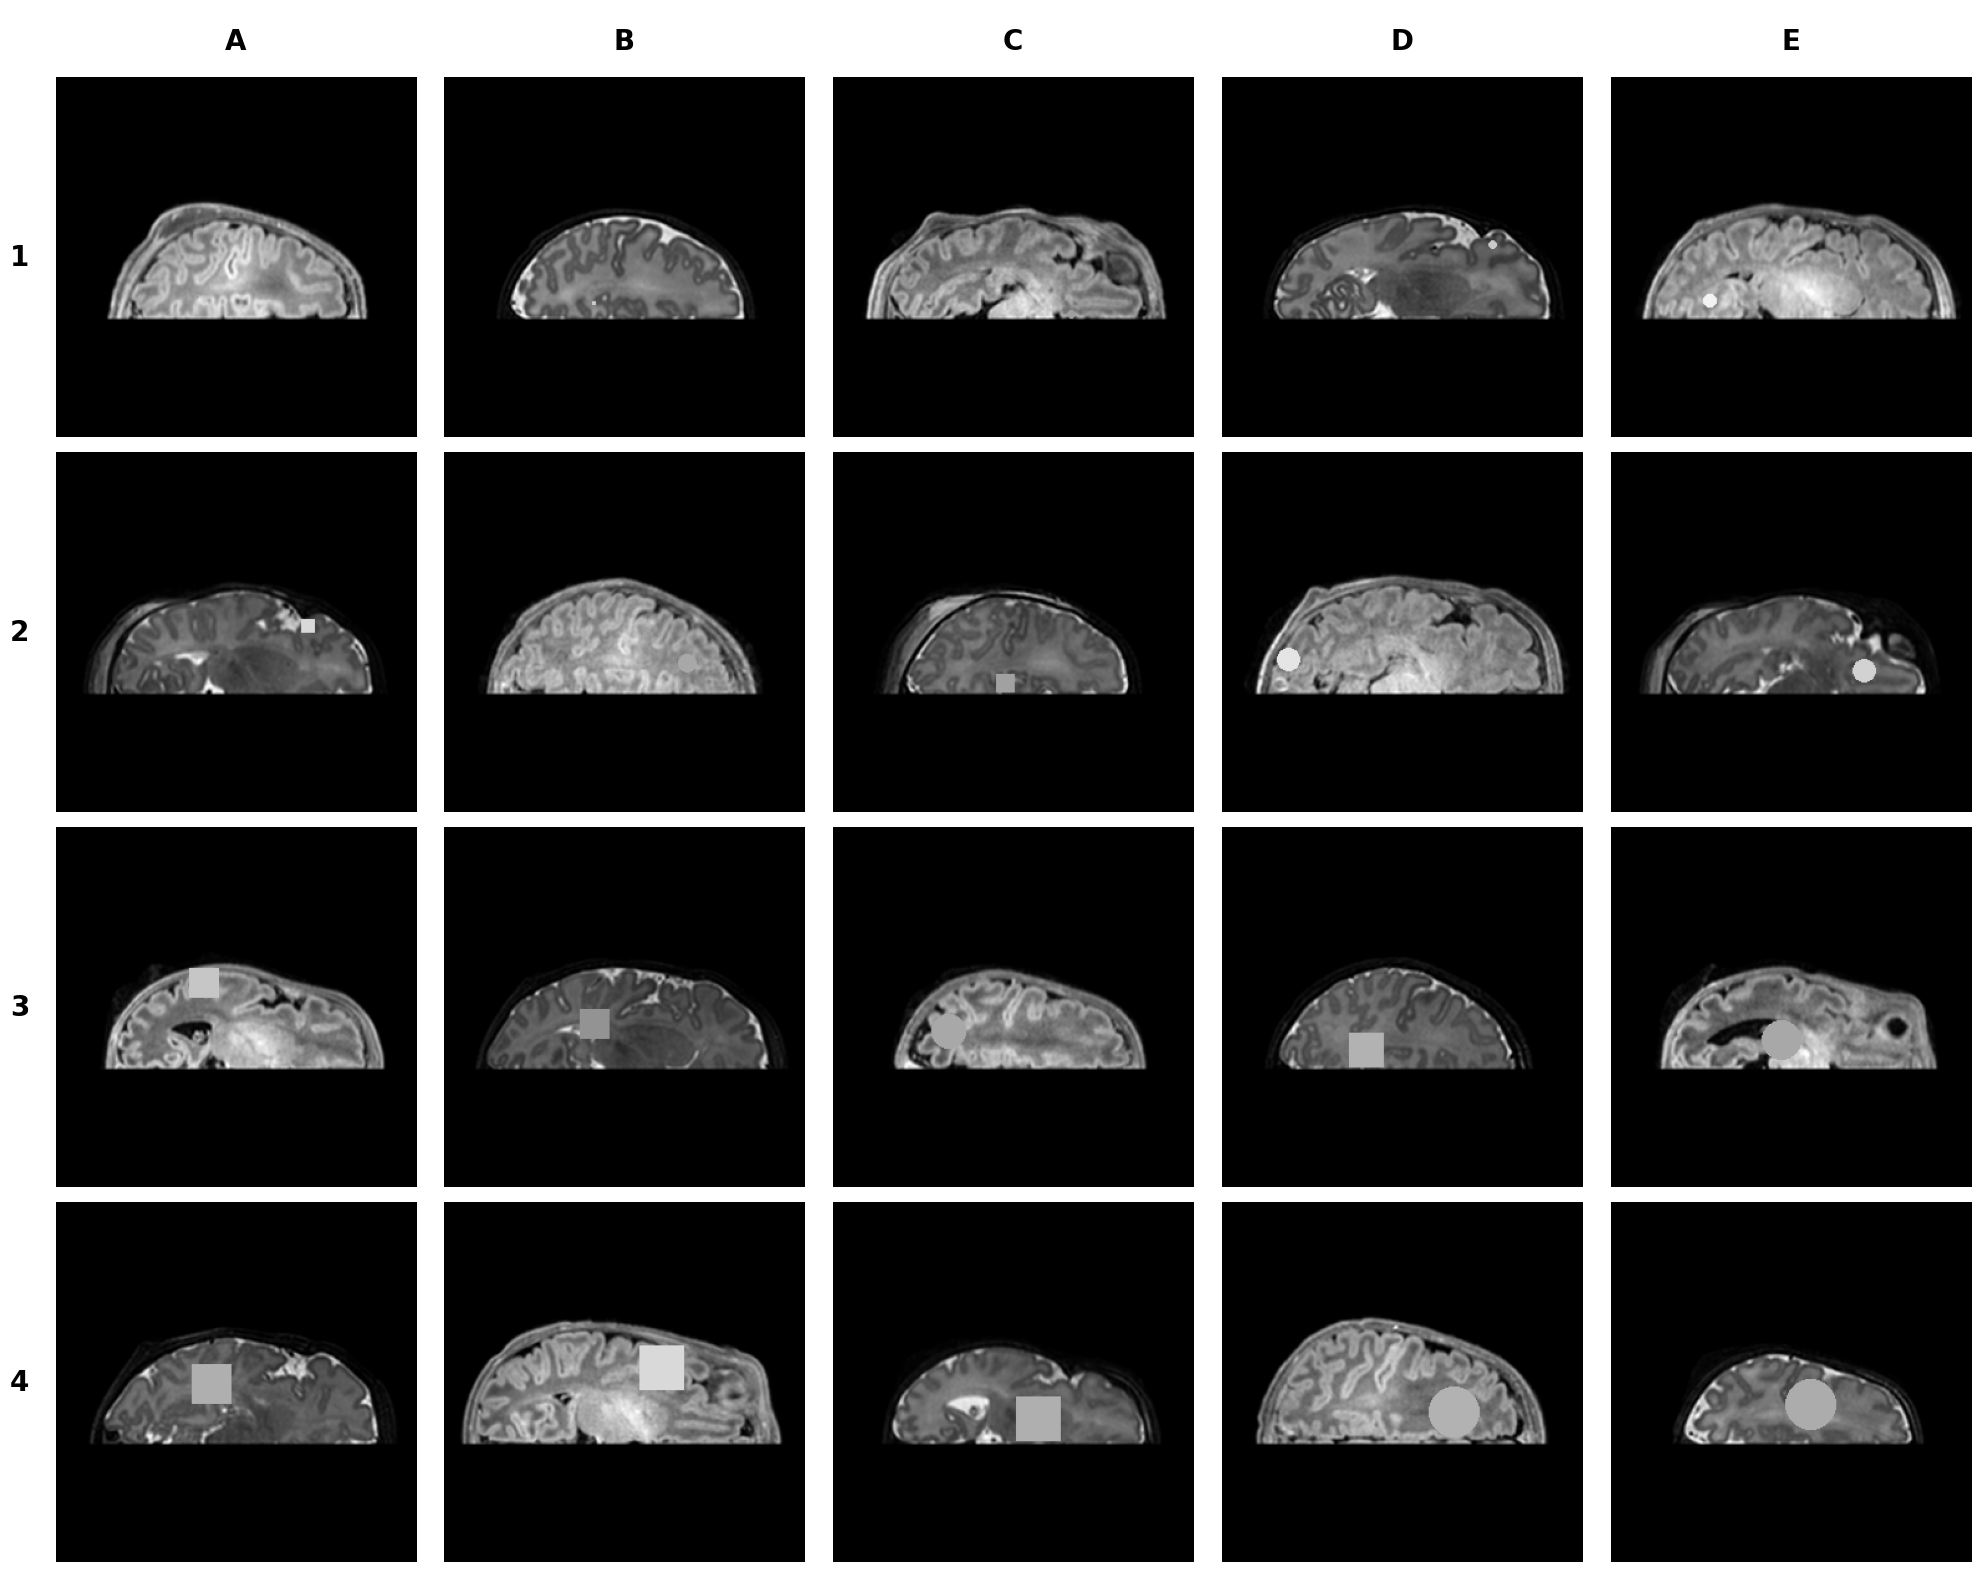

In [28]:
noise_grid(ims)

In [8]:
# len(ims)